### packages

In [1]:
import os
import sys
ultolib_dir = os.path.dirname('C:/Users/nv-group02/Desktop/Lab Folder/ultolib')
sys.path.insert(0, ultolib_dir)
from ultolib import (anritsu, korad, spincore)
from ultolib.spincore import pulse

# %matplotlib inline
from pathlib import Path
from time import sleep

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm as tqdm_bar

import qcodes as qc
from qcodes.dataset import (
    Measurement,
    initialise_or_create_database_at,
    load_or_create_experiment,
)
from qcodes.logger import start_all_logging

start_all_logging()

import qcodes.instrument_drivers.stanford_research as stanford_research




import random
import tempfile

# Pulse blaster wrapper functions 
from spinapi import *

# Pyvisa interfaces for the SR830 lockin amplifier and Anritsu RF signal generator
import pyvisa
pyvisa_rm = pyvisa.ResourceManager()

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\nv-group02\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\nv-group02\.qcodes\logs\260413-27972-qcodes.log


### template

In [ ]:

################################################################################
#
# Define and allocate temporary and output arrays
#

# log.info("Starting the loop of %d iterations" % num_delay_times)

# Tdelays_arr = np.linspace(0, MaxTdelay, num_delay_times)
# Tdelays_arr = np.logspace( np.log10(5*us), np.log10(2*ms), num_delay_times)
                   
# Tstep = MaxTdelay / num_delay_times
# LIstep = Tstep / num_data_points

################################################################################
#
# Setup and initialise the instruments : 
#   PulseBlaster, SignalGenerator, LockInAmplifier
#   pb, sg, lia are handles to our wrapper classes - not used much actually
#

# Initializse PulseBlaster
pb_set_debug(0)
pb_select_board(0)
if pb_init() != 0:
	print("Error initializing board: %s" % pb_get_error())
	input("Please press a key to continue.")
	exit(-1)
# Configure the core clock
pb_core_clock(500)

#Initialize Signal Generator
sg = pyvisa_rm.open_resource('ASRL4::INSTR')
sg.read_termination = '\r\n'
sg.baud_rate = 9600

# Initialize LockIn 
lia = pyvisa_rm.open_resource('ASRL5::INSTR')
lia.baud_rate=9600
lia.data_bits=8
lia.read_termination = '\r'
lia.write_termination = '\r\n'

################################################################################
#
# Loops in which the pulse sequence parameters change go here !
#

########################################
#
# Define some pulse sequence parameters
#
# Note that the units : ms, us are defined as multipliers in SpinCorePyWrapper 
#   all times are expected to be in ns = nanoseconds
#
Tref = 2.5*ms
Tlaser = 4*us
Tmw = 3*us

# Tmw_min = 2*us
# Tmw_max = 5*ms
# num_mw_times = 9

Tpadding = 0.25*us

# number of times sequences are repeated in each Tref
Nrepeat = 250
if( Tref / Nrepeat < Tlaser + Tmw + Tpadding ):
    print("Error in pulse sequence, Treference is too short")
    input("Please press a key to continue.")
    exit(-1)

# Frequencies are all in GHz
freq_min = 2.77
freq_max = 2.97
num_freqs = 128

freq_array = np.linspace(freq_min, freq_max, num_freqs)

# initialize output array(s)
vlockin_array = np.zeros(num_freqs)
    
lockin_settle_time = 0.2  # units are seconds, used by Python sleep() function

#-------------------------------------------------------------------------------
# Set signal generator output level and turn on before the loop
#
mwpower = -6
sg.write(f'OLVL {mwpower} DBM')
sg.write('LVL ON')


# loop over something...
for n in range(num_freqs):

    # update variables for this iteration    
    freq = freq_array[n]
    
    #---------------------------------------------------------------------------
    #
    # Program the updated pulse program 
    #
    # Define binary strings for each output channel 
    #   Note : here we use the first four channels (read right to left) for instrument control
    #          and repeat those on channels 5-8 to monitor on an oscilloscope
    #
    reference = 0b00010001
    laser     = 0b00100010
    mw_i      = 0b01000100
    mw_q      = 0b10001000
    zeros     = 0b00000000

    pb_start_programming(PULSE_PROGRAM)


    # Sanity check the parameters
    if( Tref / Nrepeat < Tlaser + Tmw + Tpadding ):
        print("Error in PulseSeq_ODMR_pulsed.")
        print("  Treference is too short for requesed repetitions Nrepeat")
        input("Please press a key to continue.")
        exit(-1)

    # time between laser and mw pulses
    Twait = Tref / Nrepeat - Tlaser - Tmw - Tpadding

    # Initiate a pulse program on the PulseBlaster
    pb_start_programming(PULSE_PROGRAM)

    # reference high
    start = pb_inst_pbonly(reference + laser, Inst.CONTINUE, 0, Tlaser)
    pb_inst_pbonly(reference, Inst.CONTINUE, 0, Twait)
    pb_inst_pbonly(reference + mw_i, Inst.CONTINUE, 0, Tmw)
    if( Nrepeat > 1 ):
        loop_high = pb_inst_pbonly(reference, Inst.LOOP, int(Nrepeat-1), Tpadding)
        pb_inst_pbonly(reference + laser, Inst.CONTINUE, 0, Tlaser)
        pb_inst_pbonly(reference, Inst.CONTINUE, 0, Twait)
        pb_inst_pbonly(reference + mw_i, Inst.END_LOOP, loop_high, Tmw)
    pb_inst_pbonly(reference, Inst.CONTINUE, 0, Tpadding)
    
    # reference low
    pb_inst_pbonly(laser, Inst.CONTINUE, 0, Tlaser)
    if( Nrepeat > 1 ):
        loop_low = pb_inst_pbonly(zeros, Inst.LOOP, int(Nrepeat-1), Tref / Nrepeat - Tlaser)
        pb_inst_pbonly(laser, Inst.END_LOOP, loop_low, Tlaser)
    pb_inst_pbonly(zeros, Inst.BRANCH, start, Tref / Nrepeat - Tlaser)

    pb_stop_programming()

    # reset the signal generator frequency 
    sg.write(f'FREQ {freq} GHZ')

    #---------------------------------------------------------------------------
    #
    # Trigger the PulseBlaster to run our sequence
    #
    
    # pb_reset()   # reset everything; this must be called before pb_start
    pb_start()   # start the sequence running

    sleep(0.1)   # wait a moment to ensure the pulse program is running


    #---------------------------------------------------------------------------
    # Python code to do data acquisition while the current pulse sequence runs
    #

    sleep(lockin_settle_time)
    
    # acquire lockin signal [I] and convert to [pA]
    R = float(lia.query('OUTP? 3')) * 1e12

    vlockin_array[n] = R

#    print("freq = " + f'{freq:6.4f}' + "    Vlockin=" + f'{R:8.2f}' )
    
    pb_stop()    # stop running the pulse sequence (leave communication open)

#
# end loop

pb_close()   # close communication with the PulseBlaster

################################################################################
#
# Process and plot the output
#
print(f'Tlaser = {Tlaser}  Tmw = {Tmw}')
plt.plot(freq_array, vlockin_array)


In [ ]:
print('V_B = 0.0 V')
print('lockin time constant = 30 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

In [ ]:
print('V_B = 0.0 V')
print('lockin time constant = 30 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

In [ ]:
print('V_B = 0.0 V')
print('lockin time constant = 100 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

In [ ]:
print('V_B = 2.0 V')
print('lockin time constant = 30 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

In [ ]:
print('V_B = 2.0 V')
print('lockin time constant = 30 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

In [ ]:
print('V_B = 2.0 V')
print('lockin time constant = 30 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

In [ ]:
print('V_B = 1.0 V')
print('lockin time constant = 30 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

In [ ]:
print('V_B = 0.0 V')
print('lockin time constant = 30 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

### iter 1

#### instruments

In [2]:
# Reset the kernel in any other open notebook before running this cell.
pulse_blaster = spincore.PulseBlasterESRPRO(name='pulse_blaster', board_number=0)
pulse_blaster.core_clock(500)   # 500 MHz -> 2 ns timing resolution

lock_in_amp = stanford_research.SR830(
    name='lock_in_amp',
    address='ASRL5::INSTR',
    terminator='\r',
)

microwave_src = anritsu.MG3681A(
    name='microwave_src',
    address='ASRL4::INSTR',
    terminator='\r\n',
)

microwave_src.output_level_unit('dBm')
microwave_src.IQ_modulation('EXT')   # CH2 of PulseBlaster gates the MW via I-input
microwave_src.pulse_modulation('EXT')   # sends PMO EXT to the Anritsu
microwave_src.power(-6)              # -6 dBm: matches template (Experiment_ODMR.ipynb, template cell)
microwave_src.output('OFF')          # DO NOT turn on until antenna is connected

pulse_blaster.stop()

2026-04-13 15:18:32,237 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ c:\Users\nv-group02\anaconda3\envs\mqst\Lib\site-packages\qcodes\instrument\instrument_base.py:188: QCoDeSDeprecationWarning: Parameter ch1_databuffer on instrument lock_in_amp does not correctly pass kwargs to its baseclass. A Parameter class must take `**kwargs` and forward them to its baseclass.
  warnings.warn(

2026-04-13 15:18:32,287 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ c:\Users\nv-group02\anaconda3\envs\mqst\Lib\site-packages\qcodes\instrument\instrument_base.py:188: QCoDeSDeprecationWarning: Parameter ch2_databuffer on instrument lock_in_amp does not correctly pass kwargs to its baseclass. A Parameter class must take `**kwargs` and forward them to its baseclass.
  warnings.warn(



Connected to: Stanford_Research_Systems SR830 (serial:s/n32132, firmware:ver1.07) in 0.28s
Connected to: ANRITSU MG3681A (serial:6100146424, firmware:3.03) in 0.13s


0

#### timing params

In [3]:
# All values from Experiment_ODMR.ipynb template cell, NOT Sewani et al.
# (Sewani uses tau_laser=5us, tau_mw=5us, tau_padding=1us — this lab uses shorter pulses.)

ref_f   = 200                  # [Hz] lock-in reference frequency
tau_ref = 1.0 / (2 * ref_f)   # [s]  half-cycle = 2.5 ms

tau_laser   = 4e-6    # [s]  4 µs laser pulse  (template: Tlaser = 4*us)
tau_mw      = 3e-6    # [s]  3 µs MW pulse     (template: Tmw = 3*us)
tau_padding = 0.25e-6 # [s]  250 ns guard time (template: Tpadding = 0.25*us)

N = 250   # repetitions per half-cycle (template: Nrepeat = 250)

# T_unit = 4 + 0.25 + 3 + 0.25 = 7.5 us per laser+MW unit
T_unit   = tau_laser + tau_padding + tau_mw + tau_padding
T_active = N * T_unit                   # 250 * 7.5 us = 1.875 ms
T_gap    = tau_ref - T_active           # 2.5 ms - 1.875 ms = 625 us idle

assert T_gap > 0, (
    f"Overflow: {N} x {T_unit*1e6:.2f} us = {T_active*1e3:.3f} ms "
    f"exceeds half-cycle of {tau_ref*1e3:.1f} ms"
)

print(f"T_unit   = {T_unit*1e6:.2f} us")
print(f"T_active = {T_active*1e3:.4f} ms  ({N} units)")
print(f"T_gap    = {T_gap*1e6:.1f} us")

T_unit   = 7.50 us
T_active = 1.8750 ms  (250 units)
T_gap    = 625.0 us


#### pulse sequence

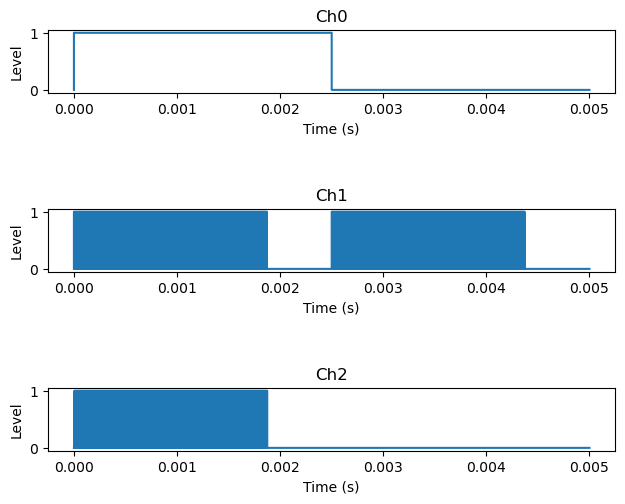

In [4]:
# Pulse sequence follows Sewani et al. 2020, Fig. 4(a) structure,
# but uses the timing values from the lab template.

pulse_blaster.reset_channel_buffer()

# CH0: 200 Hz square wave -> SR830 REF IN.
ch0_seq = [
    pulse(level=1, duration=tau_ref),   # HIGH: MW-on half-cycle
    pulse(level=0, duration=tau_ref),   # LOW:  MW-off half-cycle
]

# CH1: Laser fires in BOTH half-cycles (identical pattern -> background cancels in lock-in).
# Each unit: laser ON for tau_laser, then OFF for the MW slot.
laser_unit = [
    pulse(level=1, duration=tau_laser),
    pulse(level=0, duration=tau_padding + tau_mw + tau_padding),
]
laser_half = laser_unit * N + [pulse(level=0, duration=T_gap)]
ch1_seq = laser_half + laser_half

# CH2: MW gate fires ONLY in the first (HIGH) half-cycle.
# After the laser fires each unit, CH2 goes HIGH for tau_mw, then LOW.
mw_unit_on = [
    pulse(level=0, duration=tau_laser + tau_padding),   # wait for laser
    pulse(level=1, duration=tau_mw),                    # MW ON
    pulse(level=0, duration=tau_padding),               # trailing guard
]
mw_unit_off = [
    pulse(level=0, duration=T_unit),   # MW silent for entire unit
]

ch2_half_on  = mw_unit_on  * N + [pulse(level=0, duration=T_gap)]
ch2_half_off = mw_unit_off * N + [pulse(level=0, duration=T_gap)]
ch2_seq = ch2_half_on + ch2_half_off

pulse_blaster.ch0.pulse_sequence_buffer.set(ch0_seq)
pulse_blaster.ch1.pulse_sequence_buffer.set(ch1_seq)
pulse_blaster.ch2.pulse_sequence_buffer.set(ch2_seq)

pulse_blaster.plot_channel_buffer()   # inspect timing diagram before running

#### SR830 config

In [ ]:
lock_in_amp.reference_source.set('external')   # lock to CH0 square wave at REF IN
lock_in_amp.input_config('a')           # single-ended voltage input A

# Time constant: 30 ms to match the template's lockin_settle_time = 0.2 s.
# At 30 ms: 200 ms / 30 ms = 6.7 time constants -> > 99% settled. (SR830m.pdf, p. 3-14)
# At 100 ms: 200 ms / 100 ms = 2 time constants -> only ~86% settled -> noisy readings.
tau_c = 30e-3
lock_in_amp.time_constant(tau_c)

# Sensitivity: start at 500 uV. Adjust if OVLD lights up (increase) or signal
# is below 10% of full-scale (decrease). Valid range: 2 nV to 1 V (SR830m.pdf, p. 6-3).
lock_in_amp.sensitivity(500e-6)

# ENBW = 1/(4 * tau_c) = 1/(4 * 0.03) = 8.33 Hz
# Noise floor = 6 nV/sqrt(Hz) * sqrt(8.33) ~ 17 nVrms
# This is wider bandwidth (more noise) than 100 ms, but settle time is only 200 ms -> faster sweep.
t_settle = 0.2   # [s]  from template: lockin_settle_time = 0.2

print(f"Time constant : {tau_c*1e3:.0f} ms")
print(f"ENBW          : {1/(4*tau_c):.2f} Hz")
print(f"Noise floor   : {6e-9 * (1/(4*tau_c))**0.5 * 1e9:.1f} nVrms")
print(f"Settle time   : {t_settle*1e3:.0f} ms  ({t_settle/tau_c:.1f} time constants)")

Time constant : 30 ms
ENBW          : 8.33 Hz
Noise floor   : 17.3 nVrms
Settle time   : 200 ms  (6.7 time constants)


#### qcodes exp

In [6]:
MW_freq = qc.ManualParameter('mw_frequency', unit='Hz')
LI_R    = qc.ManualParameter('signal',       unit='V')

initialise_or_create_database_at(Path.cwd() / 'ODMR_Lab.db')

experiment = load_or_create_experiment(
    experiment_name='ODMR_Spectrum',
    sample_name='NV_diamond',
)

meas = Measurement(exp=experiment, name='zero_field_ODMR')
meas.register_parameter(MW_freq)
meas.register_parameter(LI_R, setpoints=(MW_freq,))

#### frequency sweep params

In [7]:
# From template: freq_min=2.77, freq_max=2.97, num_freqs=128 (in GHz).
# Wider range than I previously wrote (2.80-2.94): this ensures you capture
# the outer hyperfine satellites at D +/- 128 MHz (Sewani et al. 2020, Fig. 4b).
f_start   = 2.77e9   # [Hz]
f_stop    = 2.97e9   # [Hz]
n_pts     = 128

freq_list = np.linspace(f_start, f_stop, n_pts)
step_MHz  = (f_stop - f_start) / (n_pts - 1) / 1e6
total_s   = n_pts * t_settle

print(f"Sweep  : {f_start/1e9:.2f} to {f_stop/1e9:.2f} GHz")
print(f"Step   : {step_MHz:.2f} MHz  ({n_pts} points)")
print(f"Dwell  : {t_settle*1e3:.0f} ms per point")
print(f"Total  : ~{total_s:.0f} s  (~{total_s/60:.1f} min)")

Sweep  : 2.77 to 2.97 GHz
Step   : 1.57 MHz  (128 points)
Dwell  : 200 ms per point
Total  : ~26 s  (~0.4 min)


#### run sweep

In [8]:
pulse_blaster.flush_channel_buffer()   # compile and start the PulseBlaster loop
sleep(t_settle)                        # let SR830 reach steady state on reference

microwave_src.output('ON')             # only after antenna is confirmed connected

with meas.run() as datasaver:
    for f_mw in freq_list:
        microwave_src.frequency(f_mw)
        sleep(t_settle)
        r_val = lock_in_amp.R()
        datasaver.add_result((MW_freq, f_mw), (LI_R, r_val))
        print(f"  {f_mw/1e9:.4f} GHz   R = {r_val*1e6:.2f} uV")

microwave_src.output('OFF')
pulse_blaster.stop()

odmr_dataset = datasaver.dataset
print(f"\nDone. Run ID: {odmr_dataset.run_id}")

Starting experimental run with id: 5. 
  2.7700 GHz   R = 1.16 uV
  2.7716 GHz   R = 0.30 uV
  2.7731 GHz   R = 0.75 uV
  2.7747 GHz   R = 0.66 uV
  2.7763 GHz   R = 0.27 uV
  2.7779 GHz   R = 1.01 uV
  2.7794 GHz   R = 0.39 uV
  2.7810 GHz   R = 0.30 uV
  2.7826 GHz   R = 0.45 uV
  2.7842 GHz   R = 0.33 uV
  2.7857 GHz   R = 0.30 uV
  2.7873 GHz   R = 0.63 uV
  2.7889 GHz   R = 0.45 uV
  2.7905 GHz   R = 0.24 uV
  2.7920 GHz   R = 2.21 uV
  2.7936 GHz   R = 0.60 uV
  2.7952 GHz   R = 0.42 uV
  2.7968 GHz   R = 0.06 uV
  2.7983 GHz   R = 0.45 uV
  2.7999 GHz   R = 0.95 uV
  2.8015 GHz   R = 0.60 uV
  2.8031 GHz   R = 0.36 uV
  2.8046 GHz   R = 0.30 uV
  2.8062 GHz   R = 0.57 uV
  2.8078 GHz   R = 0.33 uV
  2.8094 GHz   R = 0.75 uV
  2.8109 GHz   R = 0.86 uV
  2.8125 GHz   R = 1.01 uV
  2.8141 GHz   R = 0.48 uV
  2.8157 GHz   R = 0.95 uV
  2.8172 GHz   R = 0.42 uV
  2.8188 GHz   R = 1.01 uV
  2.8204 GHz   R = 1.16 uV
  2.8220 GHz   R = 1.16 uV
  2.8235 GHz   R = 1.13 uV
  2.8251 GHz   R

#### data analysis

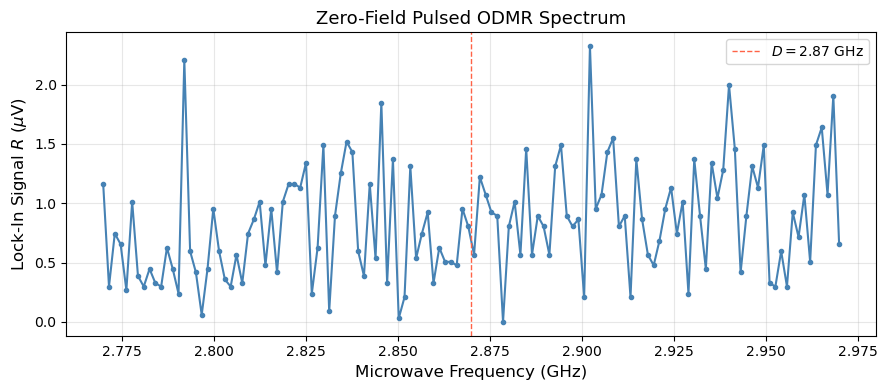

In [9]:
df = odmr_dataset.to_pandas_dataframe().reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    df['mw_frequency'] / 1e9,
    df['signal'] * 1e6,
    color='steelblue', lw=1.5, marker='o', ms=3,
)
ax.axvline(2.87, color='tomato', ls='--', lw=1, label=r'$D = 2.87\ \mathrm{GHz}$')
ax.set_xlabel('Microwave Frequency (GHz)', fontsize=12)
ax.set_ylabel(r'Lock-In Signal $R$ ($\mu$V)', fontsize=12)
ax.set_title('Zero-Field Pulsed ODMR Spectrum', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

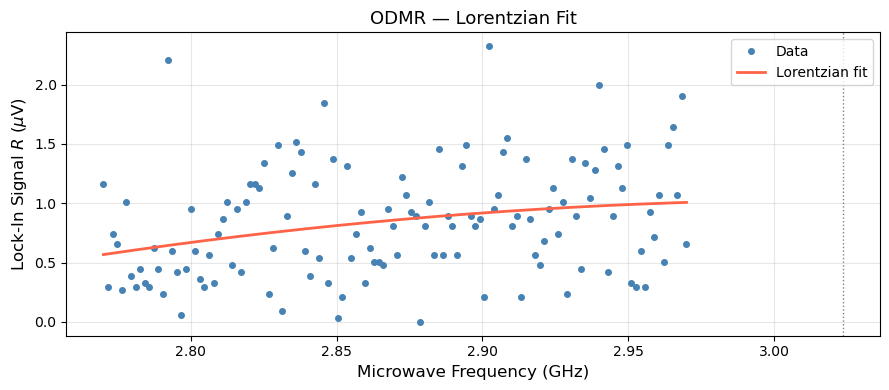

Peak center : 3.02369 +/- 804.027 MHz GHz
FWHM        : -17950.86 +/- 38280853.86 MHz
Amplitude   : 576.69 uV


In [10]:
from scipy.optimize import curve_fit

def lorentzian(f, f0, gamma, A, C):
    return A / (1.0 + ((f - f0) / gamma)**2) + C

f_arr = df['mw_frequency'].values
r_arr = df['signal'].values

p0   = [2.87e9, 5e6, r_arr.max() - r_arr.min(), r_arr.min()]
popt, pcov = curve_fit(lorentzian, f_arr, r_arr, p0=p0, maxfev=5000)
f0_fit, gamma_fit, A_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))

f_fine = np.linspace(f_arr.min(), f_arr.max(), 2000)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(f_arr / 1e9, r_arr * 1e6, 'o', ms=4, color='steelblue', label='Data')
ax.plot(f_fine / 1e9, lorentzian(f_fine, *popt) * 1e6,
        color='tomato', lw=2, label='Lorentzian fit')
ax.axvline(f0_fit / 1e9, color='gray', ls=':', lw=1)
ax.set_xlabel('Microwave Frequency (GHz)', fontsize=12)
ax.set_ylabel(r'Lock-In Signal $R$ ($\mu$V)', fontsize=12)
ax.set_title('ODMR — Lorentzian Fit', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak center : {f0_fit/1e9:.5f} +/- {perr[0]/1e6:.3f} MHz GHz")
print(f"FWHM        : {2*gamma_fit/1e6:.2f} +/- {2*perr[1]/1e6:.2f} MHz")
print(f"Amplitude   : {A_fit*1e6:.2f} uV")

### iter 2

#### instruments

In [2]:
# Reset the kernel in any other open notebook before running this cell.
pulse_blaster = spincore.PulseBlasterESRPRO(name='pulse_blaster', board_number=0)
pulse_blaster.core_clock(500)   # 500 MHz clock -> 2 ns resolution

lock_in_amp = stanford_research.SR830(
    name='lock_in_amp',
    address='ASRL5::INSTR',
    terminator='\r',
)

microwave_src = anritsu.MG3681A(
    name='microwave_src',
    address='ASRL4::INSTR',
    terminator='\r\n',
)

# Template: sg.write('OLVL {mwpower} DBM') then sg.write('LVL ON') before the loop.
# LVL ON is deferred to the sweep cell (antenna must be connected first).
microwave_src.output_level_unit('dBm')
microwave_src.IQ_modulation('EXT')   # CH2 gates MW via Anritsu I-input
microwave_src.power(-6)              # template: mwpower = -6
microwave_src.output('OFF')

pulse_blaster.stop()

2026-04-13 16:10:15,579 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ c:\Users\nv-group02\anaconda3\envs\mqst\Lib\site-packages\qcodes\instrument\instrument_base.py:188: QCoDeSDeprecationWarning: Parameter ch1_databuffer on instrument lock_in_amp does not correctly pass kwargs to its baseclass. A Parameter class must take `**kwargs` and forward them to its baseclass.
  warnings.warn(

2026-04-13 16:10:15,633 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ c:\Users\nv-group02\anaconda3\envs\mqst\Lib\site-packages\qcodes\instrument\instrument_base.py:188: QCoDeSDeprecationWarning: Parameter ch2_databuffer on instrument lock_in_amp does not correctly pass kwargs to its baseclass. A Parameter class must take `**kwargs` and forward them to its baseclass.
  warnings.warn(



Connected to: Stanford_Research_Systems SR830 (serial:s/n32132, firmware:ver1.07) in 0.29s
Connected to: ANRITSU MG3681A (serial:6100146424, firmware:3.03) in 0.13s


0

#### timing params

In [ ]:
# All times in nanoseconds — matches the template's spinapi unit convention
# (template: ms=1000000, us=1000, so Tref=2.5*ms=2500000, Tlaser=4*us=4000, etc.)

Tref     = 2_500_000   # ns  (2.5 ms half-period -> 200 Hz reference)
Tlaser   = 4_000       # ns  (4 µs)   template: Tlaser = 4*us
Tmw      = 3_000       # ns  (3 µs)   template: Tmw = 3*us
Tpadding = 250         # ns  (0.25 µs) template: Tpadding = 0.25*us
Nrepeat  = 250         # template: Nrepeat = 250

Tunit = Tref // Nrepeat                    # 10000 ns per laser+MW unit
Twait = Tunit - Tlaser - Tmw - Tpadding   # 2750 ns between laser and MW

assert Twait > 0, "Treference is too short for requested Nrepeat"

# Channel bitmasks — template uses 8-bit patterns with bits 4-7 mirroring 0-3
# for oscilloscope monitoring.  The QCodes driver uses 4 channels (bits 0-3).
# FLAG_MASK (bits 21-23) is ORed in automatically by send_instruction.
reference = 0b00010001   # CH0 -> SR830 REF IN
laser     = 0b00100010   # CH1 -> AOM / laser gate
mw_i      = 0b01000100   # CH2 -> Anritsu I-input (MW gate)
zeros     = 0b00000000

print(f"Tunit  = {Tunit} ns  ({Tunit/1e3:.1f} µs)")
print(f"Twait  = {Twait} ns  ({Twait/1e3:.2f} µs)")
print(f"T_HIGH = {Tref} ns  ({Tref/1e6:.1f} ms) [verified]")
print(f"T_LOW  = {Tref} ns  ({Tref/1e6:.1f} ms) [verified]")

Tunit  = 10000 ns  (10.0 µs)
Twait  = 2750 ns  (2.75 µs)
T_HIGH = 2500000 ns  (2.5 ms) [verified]
T_LOW  = 2500000 ns  (2.5 ms) [verified]


#### pulse sequence

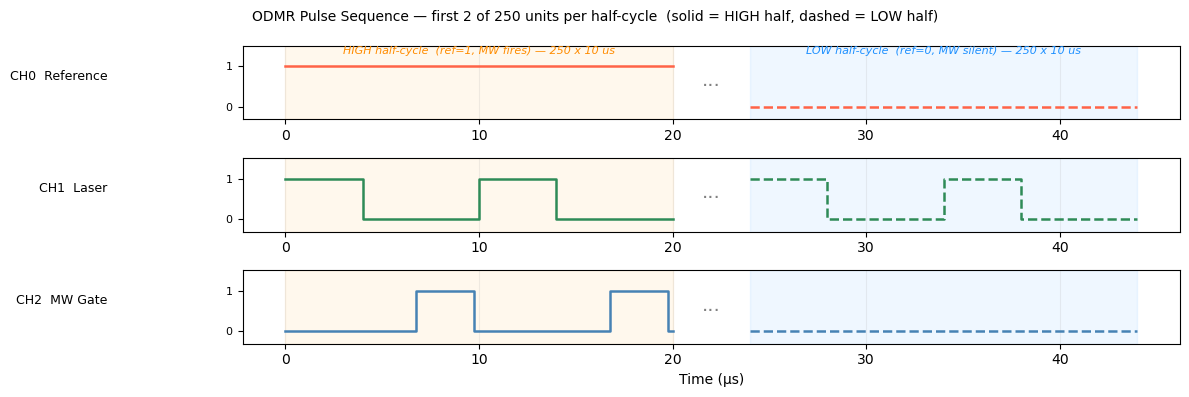

In [ ]:
# The pulse sequence is the same for every MW frequency, so we program once
# here rather than inside the sweep loop (unlike the template which reprograms
# each iteration — the sequence itself never changes between iterations).
#
# Sequence structure mirrors the template exactly:
#
#  HIGH half (reference=1, MW fires):
#    [laser+ref] -> [wait+ref] -> [mw+ref]          <- first unit (no padding before)
#    LOOP x(Nrepeat-1):
#      [padding+ref] -> [laser+ref] -> [wait+ref] -> [mw+ref END_LOOP]
#    [padding+ref]                                   <- close out final unit
#
#  LOW half (reference=0, MW silent):
#    [laser] -> LOOP x(Nrepeat-1): [zeros] -> [laser END_LOOP] -> [zeros BRANCH->start]

pulse_blaster.start_programming()

# ── HIGH half-cycle ───────────────────────────────────────────────────────────
start = pulse_blaster.send_instruction(
    reference | laser, 'CONTINUE', 0, Tlaser)       # laser ON, ref HIGH

pulse_blaster.send_instruction(
    reference, 'CONTINUE', 0, Twait)                # wait (laser OFF, mw OFF)

pulse_blaster.send_instruction(
    reference | mw_i, 'CONTINUE', 0, Tmw)           # MW ON, ref HIGH

loop_high = pulse_blaster.send_instruction(
    reference, 'LOOP', Nrepeat - 1, Tpadding)       # padding; loop Nrepeat-1 more times

pulse_blaster.send_instruction(
    reference | laser, 'CONTINUE', 0, Tlaser)       # laser ON

pulse_blaster.send_instruction(
    reference, 'CONTINUE', 0, Twait)                # wait

pulse_blaster.send_instruction(
    reference | mw_i, 'END_LOOP', loop_high, Tmw)   # MW ON, close loop

pulse_blaster.send_instruction(
    reference, 'CONTINUE', 0, Tpadding)             # final padding to complete last unit

# ── LOW half-cycle ────────────────────────────────────────────────────────────
pulse_blaster.send_instruction(
    laser, 'CONTINUE', 0, Tlaser)                   # laser ON, ref LOW, MW OFF

loop_low = pulse_blaster.send_instruction(
    zeros, 'LOOP', Nrepeat - 1, Tunit - Tlaser)     # zeros for remainder of unit; loop

pulse_blaster.send_instruction(
    laser, 'END_LOOP', loop_low, Tlaser)             # laser ON, close loop

pulse_blaster.send_instruction(
    zeros, 'BRANCH', start, Tunit - Tlaser)         # zeros, branch back to start

pulse_blaster.stop_programming()

def plot_sequence():
    def _segs_to_xy(segs):
        """Convert [(duration_ns, level), ...] to (x_us, y) arrays."""
        xs, ys, t = [], [], 0.0
        for dur, lvl in segs:
            xs += [t / 1e3, (t + dur) / 1e3]
            ys += [lvl, lvl]
            t  += dur
        return xs, ys

    def _high_segs(ch, n):
        """First n units of the HIGH half for channel ch."""
        # First unit has no leading padding (matches template: start = first instruction)
        segs = [(Tlaser, ch in (0, 1)), (Twait, ch == 0), (Tmw, ch in (0, 2))]
        for _ in range(n - 1):
            segs += [(Tpadding, ch == 0), (Tlaser, ch in (0, 1)),
                    (Twait,    ch == 0), (Tmw,    ch in (0, 2))]
        segs += [(Tpadding, ch == 0)]   # final padding closing the last unit
        return [(d, int(v)) for d, v in segs]

    def _low_segs(ch, n):
        """First n units of the LOW half for channel ch."""
        # Instruction before loop: laser once
        segs = [(Tlaser, ch == 1)]
        for _ in range(n - 1):
            segs += [(Tunit - Tlaser, 0), (Tlaser, ch == 1)]
        segs += [(Tunit - Tlaser, 0)]   # final zeros (BRANCH)
        return [(d, int(v)) for d, v in segs]

    N_show    = 2
    gap_us    = 4.0   # visual gap between HIGH and LOW panels (µs)
    ch_labels = ['CH0  Reference', 'CH1  Laser', 'CH2  MW Gate']
    colors    = ['tomato', 'seagreen', 'steelblue']

    fig, axes = plt.subplots(3, 1, figsize=(12, 4), sharex=False)

    for i, ax in enumerate(axes):
        xh, yh = _segs_to_xy(_high_segs(i, N_show))
        xl, yl = _segs_to_xy(_low_segs(i,  N_show))

        t_end_high = xh[-1]
        xl = [x + t_end_high + gap_us for x in xl]
        t_end_low  = xl[-1]
        mid_high   = t_end_high / 2
        mid_low    = (t_end_high + gap_us + t_end_low) / 2

        ax.plot(xh, yh, lw=1.8, color=colors[i])
        ax.plot(xl, yl, lw=1.8, color=colors[i], ls='--')
        ax.text(t_end_high + gap_us / 2, 0.5, '···',
                ha='center', va='center', fontsize=14, color='gray')

        ax.axvspan(0,                  t_end_high,  alpha=0.07, color='orange')
        ax.axvspan(t_end_high + gap_us, t_end_low,  alpha=0.07, color='dodgerblue')

        ax.set_ylim(-0.3, 1.5)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['0', '1'], fontsize=8)
        ax.set_ylabel(ch_labels[i], fontsize=9, rotation=0, ha='right', labelpad=85)
        ax.grid(True, alpha=0.2, axis='x')

        if i == 0:
            ax.text(mid_high, 1.3,
                    f'HIGH half-cycle  (ref=1, MW fires) — {Nrepeat} x {Tunit/1e3:.0f} us',
                    ha='center', fontsize=8, color='darkorange', style='italic')
            ax.text(mid_low, 1.3,
                    f'LOW half-cycle  (ref=0, MW silent) — {Nrepeat} x {Tunit/1e3:.0f} us',
                    ha='center', fontsize=8, color='dodgerblue', style='italic')

    axes[-1].set_xlabel('Time (µs)', fontsize=10)
    fig.suptitle(
        f'ODMR Pulse Sequence — first {N_show} of {Nrepeat} units per half-cycle  '
        f'(solid = HIGH half, dashed = LOW half)',
        fontsize=10)
    plt.tight_layout()
    plt.show()
plot_sequence()

#### SR830 config

In [36]:
# External reference from PulseBlaster CH0 wired to SR830 REF IN.
lock_in_amp.reference_source.set('external')
lock_in_amp.input_config('a') 
# lock_in_amp.input_config('I 1M')

# Template plot cells say: "lockin time constant = 30 ms"
# With lockin_settle_time = 0.2 s: 200 ms / 30 ms = 6.7 tau_c -> >99% settled.
tau_c = 30e-3
lock_in_amp.time_constant(tau_c)
lock_in_amp.sensitivity(500e-6)

lockin_settle_time = 0.2   # s — matches template exactly

print(f"Time constant : {tau_c*1e3:.0f} ms")
print(f"Settle time   : {lockin_settle_time*1e3:.0f} ms  ({lockin_settle_time/tau_c:.1f} tau_c)")

Time constant : 30 ms
Settle time   : 200 ms  (6.7 tau_c)


#### qcodes setup

In [37]:
MW_freq = qc.ManualParameter('mw_frequency', unit='Hz')
LI_R    = qc.ManualParameter('signal',       unit='V')

initialise_or_create_database_at(Path.cwd() / 'ODMR_Lab.db')

experiment = load_or_create_experiment(
    experiment_name='ODMR_Spectrum',
    sample_name='NV_diamond',
)

meas = Measurement(exp=experiment, name='zero_field_ODMR')
meas.register_parameter(MW_freq)
meas.register_parameter(LI_R, setpoints=(MW_freq,))

#### frequency sweep params

In [38]:
# Template: freq_min=2.77, freq_max=2.97, num_freqs=128 (GHz values)
# QCodes MG3681A parameter expects Hz, so convert here.
freq_min = 2.07e9   # Hz
freq_max = 2.67e9   # Hz
num_freqs = 128

freq_list = np.linspace(freq_min, freq_max, num_freqs)

print(f"Sweep : {freq_min/1e9:.2f} to {freq_max/1e9:.2f} GHz  ({num_freqs} pts)")
print(f"Step  : {(freq_max-freq_min)/(num_freqs-1)/1e6:.2f} MHz")
print(f"Total : ~{num_freqs * lockin_settle_time:.0f} s")

Sweep : 2.07 to 2.67 GHz  (128 pts)
Step  : 4.72 MHz
Total : ~26 s


#### run sweep

In [39]:
# Template: sg.write('LVL ON') before the loop, then pb_start() inside each
# iteration.  Here we start PB once and leave it running — the sequence loops
# continuously on hardware and the frequency is the only thing that changes.

pulse_blaster.start()
sleep(0.1)   # template: sleep(0.1) after pb_start to ensure program is running

microwave_src.output('ON')   # antenna must be connected before this line

with meas.run() as datasaver:
    for f_mw in tqdm_bar(freq_list, desc='ODMR sweep', unit='pt'):
        microwave_src.frequency(f_mw)
        sleep(lockin_settle_time)
        r_val = lock_in_amp.R()
        datasaver.add_result((MW_freq, f_mw), (LI_R, r_val))

microwave_src.output('OFF')
pulse_blaster.stop()

odmr_dataset = datasaver.dataset
print(f"Done. Run ID: {odmr_dataset.run_id}")

Starting experimental run with id: 18. 


ODMR sweep:   0%|          | 0/128 [00:00<?, ?pt/s]

Done. Run ID: 18


#### data analysis

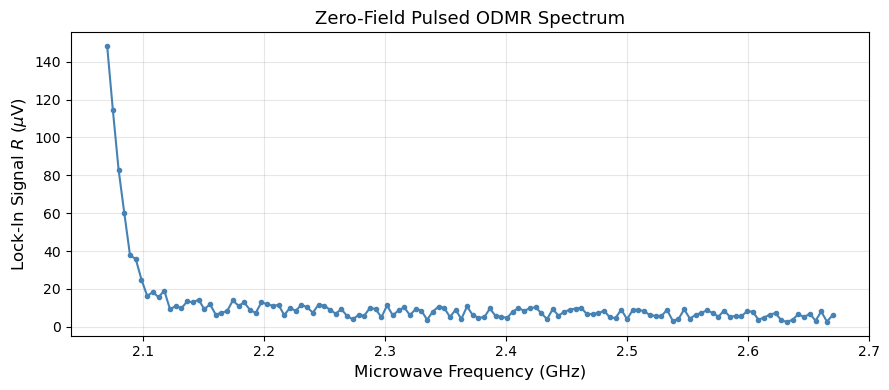

In [40]:
df = odmr_dataset.to_pandas_dataframe().reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    df['mw_frequency'] / 1e9,
    df['signal'] * 1e6,
    color='steelblue', lw=1.5, marker='o', ms=3,
)
# ax.axvline(2.87, color='tomato', ls='--', lw=1, label=r'$D = 2.87\ \mathrm{GHz}$')
ax.set_xlabel('Microwave Frequency (GHz)', fontsize=12)
ax.set_ylabel(r'Lock-In Signal $R$ ($\mu$V)', fontsize=12)
ax.set_title('Zero-Field Pulsed ODMR Spectrum', fontsize=13)
# ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

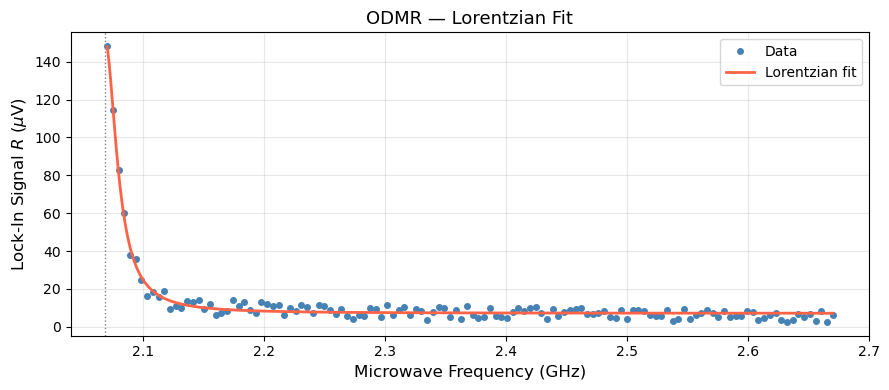

Peak center : 2.06783 +/- 0.769 MHz GHz
FWHM        : -23.69 +/- 0.88 MHz
Amplitude   : 145.60 uV


In [41]:
from scipy.optimize import curve_fit

def lorentzian(f, f0, gamma, A, C):
    return A / (1.0 + ((f - f0) / gamma)**2) + C

f_arr = df['mw_frequency'].values
r_arr = df['signal'].values

p0   = [2.87e9, 5e6, r_arr.max() - r_arr.min(), r_arr.min()]
popt, pcov = curve_fit(lorentzian, f_arr, r_arr, p0=p0, maxfev=5000)
f0_fit, gamma_fit, A_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))

f_fine = np.linspace(f_arr.min(), f_arr.max(), 2000)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(f_arr / 1e9, r_arr * 1e6, 'o', ms=4, color='steelblue', label='Data')
ax.plot(f_fine / 1e9, lorentzian(f_fine, *popt) * 1e6,
        color='tomato', lw=2, label='Lorentzian fit')
ax.axvline(f0_fit / 1e9, color='gray', ls=':', lw=1)
ax.set_xlabel('Microwave Frequency (GHz)', fontsize=12)
ax.set_ylabel(r'Lock-In Signal $R$ ($\mu$V)', fontsize=12)
ax.set_title('ODMR — Lorentzian Fit', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak center : {f0_fit/1e9:.5f} +/- {perr[0]/1e6:.3f} MHz GHz")
print(f"FWHM        : {2*gamma_fit/1e6:.2f} +/- {2*perr[1]/1e6:.2f} MHz")
print(f"Amplitude   : {A_fit*1e6:.2f} uV")

### end